In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow version: {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0


In [114]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'데이터 기간: {df["Date"].min().date()} ~ {df["Date"].max().date()}')
print(f'총 샘플 수: {len(df)}')
df[['Date', 'Open']].head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 기간: 2010-06-29 ~ 2022-03-24
총 샘플 수: 2956


,Date,Open
0,2010-06-29,3.800
1,2010-06-30,5.158
2,2010-07-01,5.000
3,2010-07-02,4.600
4,2010-07-06,4.000


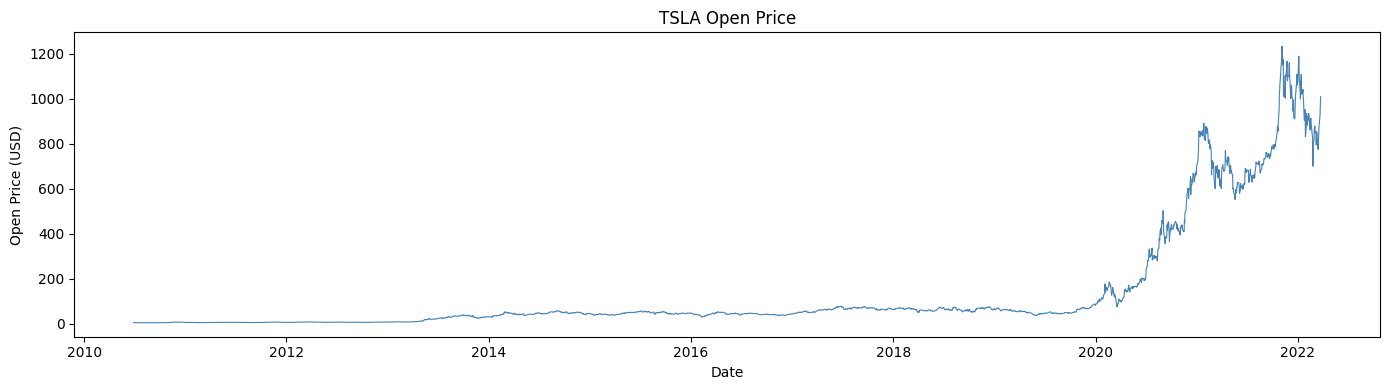

In [115]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Open'], color='steelblue', linewidth=0.8)
plt.title('TSLA Open Price')
plt.xlabel('Date')
plt.ylabel('Open Price (USD)')
plt.tight_layout()
plt.show()

In [116]:
# ── 하이퍼파라미터 ──────────────────────────
WINDOW_SIZE = 20
TRAIN_RATIO = 0.8
# ────────────────────────────────────────────

prices = df['Open'].values.astype(np.float32)
split_idx = int(len(prices) * TRAIN_RATIO)

def make_sequences_relative(prices, window):
    """
    시퀀스 단위 상대 정규화.
    X: 윈도우를 첫 값으로 나눈 상대값 (shape: N, window, 1)
    y: 다음 날 가격을 첫 값으로 나눈 상대값 (shape: N, 1)
    base: 각 시퀀스의 기준 가격 prices[i] (역산에 사용)
    """
    X, y, base = [], [], []
    for i in range(len(prices) - window):
        b = prices[i]
        X.append((prices[i : i + window] / b).reshape(-1, 1))
        y.append(prices[i + window] / b)
        base.append(b)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1),
            np.array(base, dtype=np.float32))

X_all, y_all, base_all = make_sequences_relative(prices, WINDOW_SIZE)

train_size = split_idx - WINDOW_SIZE
X_train, y_train          = X_all[:train_size], y_all[:train_size]
X_test,  y_test, base_test = X_all[train_size:], y_all[train_size:], base_all[train_size:]

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')
print(f'y_train 범위: {y_train.min():.4f} ~ {y_train.max():.4f}')
print(f'y_test  범위: {y_test.min():.4f} ~ {y_test.max():.4f}')

X_train: (2344, 20, 1), y_train: (2344, 1)
X_test : (592, 20, 1),  y_test : (592, 1)
y_train 범위: 0.6650 ~ 2.1322
y_test  범위: 0.4109 ~ 2.0611


In [117]:
model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    SimpleRNN(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)   # 회귀 출력 — activation 없음 (linear)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 20, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0915 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0271 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0217 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0189 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0146 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0130 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0123 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0109 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0111 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 10/1

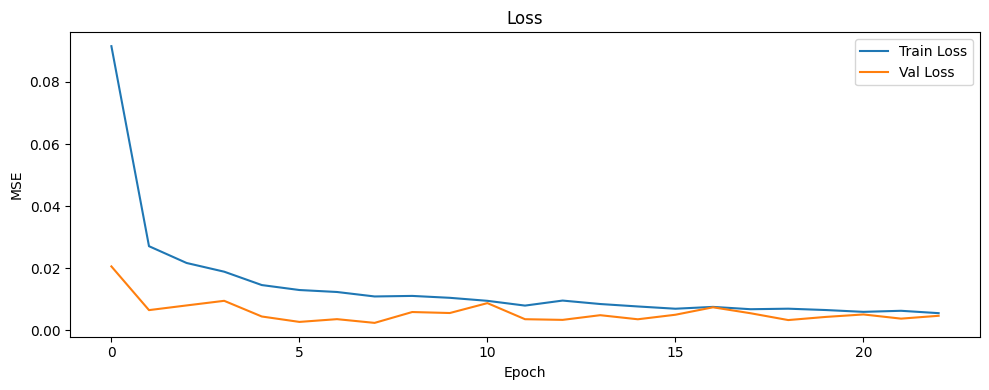

In [119]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
# 상대 예측값 → 실제 가격 복원
y_pred_rel = model.predict(X_test).flatten()
y_pred = y_pred_rel * base_test
y_true = y_test.flatten() * base_test

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('=== 테스트 성능 ===')
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
=== 테스트 성능 ===
  MSE  : 1480.8470
  RMSE : 38.4818
  MAE  : 26.8009
  MAPE : 5.51%


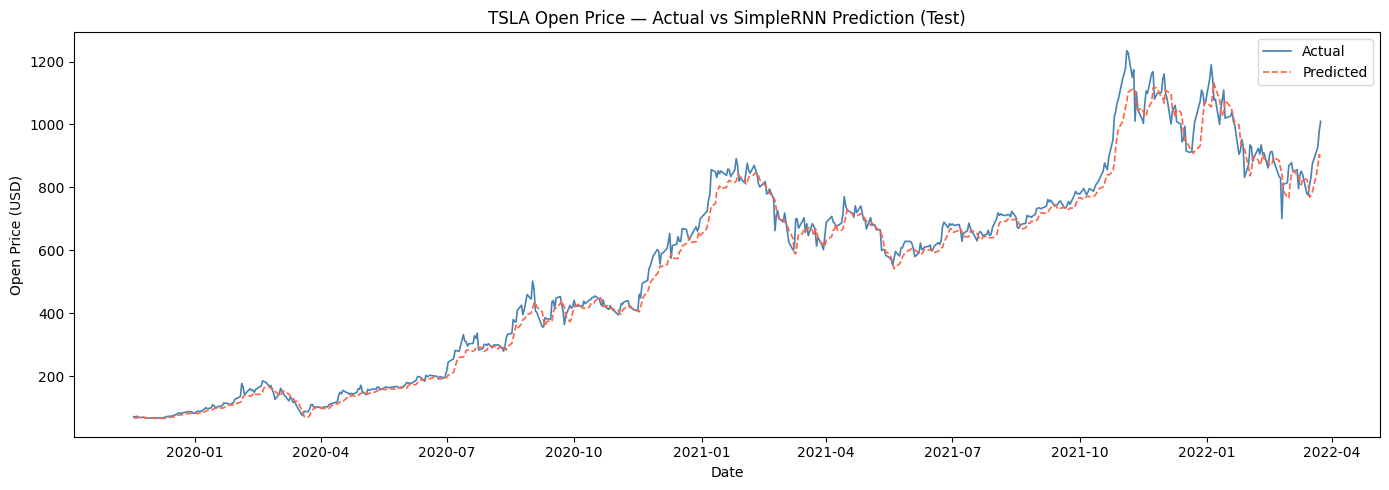

In [125]:
# 테스트 구간 날짜 — y_true 길이에 맞게 끝에서 자름
test_dates = df['Date'].values[-len(y_true):]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true, label='Actual',    color='steelblue', linewidth=1.2)
plt.plot(test_dates, y_pred, label='Predicted', color='tomato',    linewidth=1.2, linestyle='--')
plt.title('TSLA Open Price — Actual vs SimpleRNN Prediction (Test)')
plt.xlabel('Date')
plt.ylabel('Open Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [123]:
last_base   = prices[-WINDOW_SIZE]                              # 기준값
last_window = (prices[-WINDOW_SIZE:] / last_base).reshape(1, WINDOW_SIZE, 1)

next_rel   = model.predict(last_window)[0, 0]
next_price = next_rel * last_base

print(f'마지막 데이터 날짜  : {df["Date"].max().date()}')
print(f'마지막 실제 Open  : ${prices[-1]:.4f}')
print(f'예측 다음 날 Open : ${next_price:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
마지막 데이터 날짜  : 2022-03-24
마지막 실제 Open  : $1009.7300
예측 다음 날 Open : $943.3848
